# Import and setup

In [8]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 97 (delta 48), reused 82 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 215.59 KiB | 21.56 MiB/s, done.
Resolving deltas: 100% (48/48), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from src.clean_data import normalize
from src.preprocessing import augment, extract_hog, skltn
import src.evaluate as eva

from joblib import Parallel, delayed
from src.preprocessing import data_process
import gc

# Load data

In [10]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

#Clean data
train, test = normalize(train, test)

gc.collect()

0

# Preprocessing

In [12]:
#This cell use to unflatten image
X = train.drop('label', axis = 1)
y = train['label']
img = X.values.reshape(-1, 28, 28)
test_img = test.values.reshape(-1, 28, 28)


In [ ]:
# Augment + Skeletonize + Hog 

X = data_process(img, True)
test = data_process(test_img, False)

y = np.repeat(y, 2)

# Clean 
del img, test_img
gc.collect()


96

In [14]:
pd.DataFrame(X).to_csv('X.csv', index = False)
pd.DataFrame(test).to_csv('test.csv', index = False)

gc.collect()

0

In [15]:
# Shuffle 
idx = np.random.permutation(len(X))

X = X[idx]
y = y.iloc[idx]

gc.collect()

0

In [16]:
# This cell use to split train-test

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Model selection + Train model

In [17]:
model = RandomForestClassifier(n_estimators = 100, oob_score=True, random_state = 42)

model.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

# Evaluation

OOB Score: 0.9619791666666667
Accuracy = 96.79


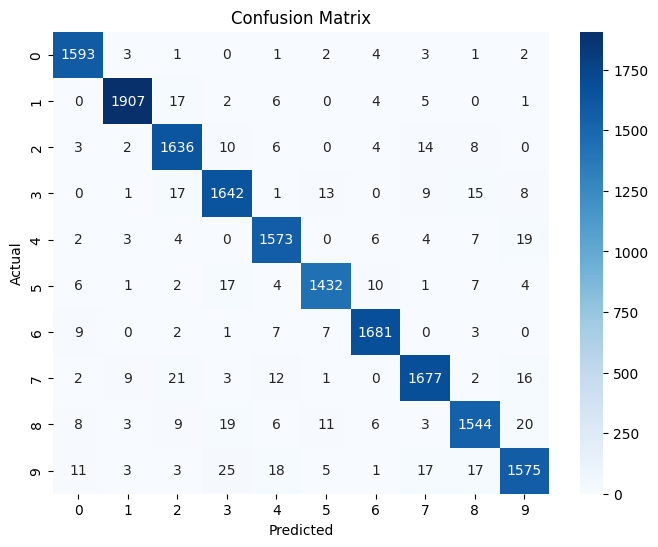

ValueError: Unable to coerce to Series, length must be 1: given 16800

In [18]:
y_pred = model.predict(X_val)
print(f'OOB Score: {model.oob_score_}')
eva.evaluate(y_val, y_pred)
eva.showWrongCase(model, pd.DataFrame(X_val), pd.DataFrame(y_val)) 

# Submission

In [27]:
gc.collect()
from src.submit import submit
submit(X, y, test, model)
submission = pd.read_csv('submission.csv')
submission = submission.iloc[:28000]
print(submission.shape)
submission.to_csv('submission.csv', index=False)

(28000, 2)


In [28]:
!kaggle competitions submit -c digit-recognizer -f submission.csv  -m "00:49AM, Worth it?"

100% 208k/208k [00:00<00:00, 848kB/s]
Successfully submitted to Digit Recognizer